In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('revenue_streams.csv')
print(df)

      Income_Stream  Year_1_Revenue  Churn_Risk Stability
0  Fertilizer_Sales      5927862.09        0.15    Medium
1     Rental_Income      1279410.88        0.10      High
2    PDS_Commission       936447.31        0.20      High
3       Food_Grains       173232.00        0.35       Low
4    MSP_Commission        25650.00        0.40       Low


In [2]:
years = np.arange(0, 8)

for stream in df['Income_Stream']:
    churn = df[df['Income_Stream'] == stream]['Churn_Risk'].values[0]
    retention = (1 - churn) ** years * 100
    print(f"{stream}: {retention}")

Fertilizer_Sales: [100.          85.          72.25        61.4125      52.200625
  44.37053125  37.71495156  32.05770883]
Rental_Income: [100.       90.       81.       72.9      65.61     59.049    53.1441
  47.82969]
PDS_Commission: [100.       80.       64.       51.2      40.96     32.768    26.2144
  20.97152]
Food_Grains: [100.          65.          42.25        27.4625      17.850625
  11.60290625   7.54188906   4.90222789]
MSP_Commission: [100.       60.       36.       21.6      12.96      7.776     4.6656
   2.79936]


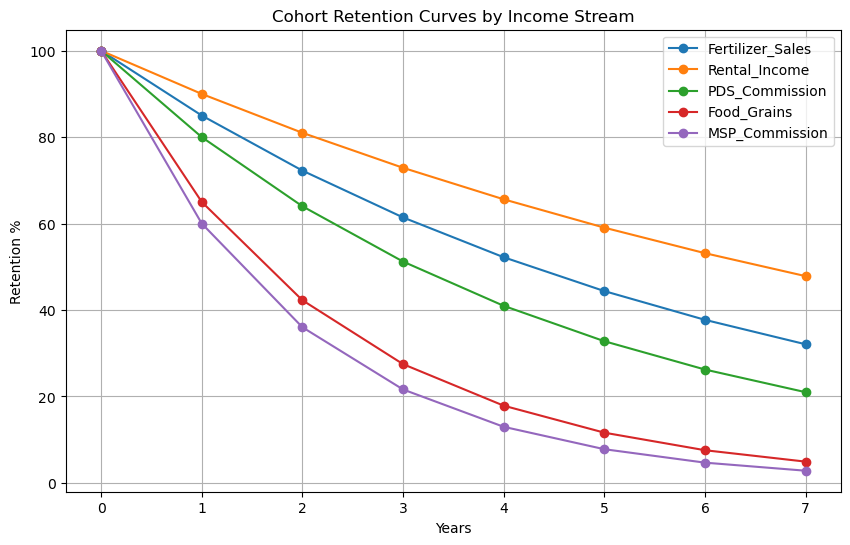

In [3]:
import matplotlib.pyplot as plt

years = np.arange(0, 8)

plt.figure(figsize=(10, 6))

for stream in df['Income_Stream']:
    churn = df[df['Income_Stream'] == stream]['Churn_Risk'].values[0]
    retention = (1 - churn) ** years * 100
    plt.plot(years, retention, marker='o', label=stream)

plt.title('Cohort Retention Curves by Income Stream')
plt.xlabel('Years')
plt.ylabel('Retention %')
plt.legend()
plt.grid(True)
plt.show()

Saved as retention_curves.png


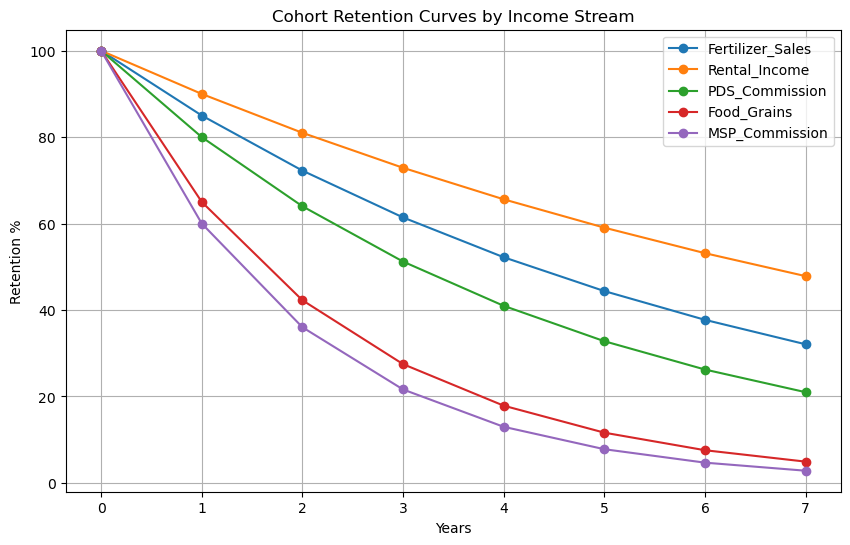

In [4]:
plt.figure(figsize=(10, 6))

for stream in df['Income_Stream']:
    churn = df[df['Income_Stream'] == stream]['Churn_Risk'].values[0]
    retention = (1 - churn) ** years * 100
    plt.plot(years, retention, marker='o', label=stream)

plt.title('Cohort Retention Curves by Income Stream')
plt.xlabel('Years')
plt.ylabel('Retention %')
plt.legend()
plt.grid(True)

plt.savefig('retention_curves.png')
print("Saved as retention_curves.png")

In [5]:
discount = 0.09

df['CLV'] = (df['Year_1_Revenue'] * 0.65) * (1 + discount) / (discount + df['Churn_Risk'])
df['CLV_Lakhs'] = df['CLV'] / 100000

print(df[['Income_Stream', 'CLV_Lakhs']])

      Income_Stream   CLV_Lakhs
0  Fertilizer_Sales  174.995429
1     Rental_Income   47.708558
2    PDS_Commission   22.878377
3       Food_Grains    2.789429
4    MSP_Commission    0.370878


Saved as clv_comparison.png


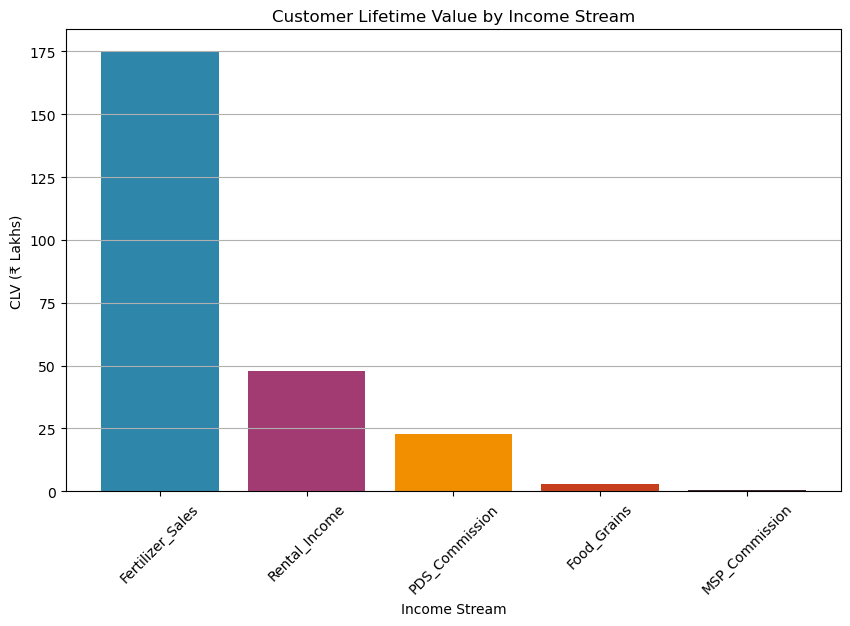

In [6]:
plt.figure(figsize=(10, 6))
plt.bar(df['Income_Stream'], df['CLV_Lakhs'], color=['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B'])
plt.title('Customer Lifetime Value by Income Stream')
plt.xlabel('Income Stream')
plt.ylabel('CLV (₹ Lakhs)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.savefig('clv_comparison.png')
print("Saved as clv_comparison.png")
plt.show()

In [7]:
total_revenue = df['Year_1_Revenue'].sum()
pat_margin = 0.70

scenarios = {
    'Base_Case': 0,
    '10pct_Churn': 0.10,
    '20pct_Churn': 0.20,
    '30pct_Churn': 0.30,
    'Lose_Fertilizer': 0.711,
    'Lose_Rental': 0.153
}

for name, loss in scenarios.items():
    new_revenue = total_revenue * (1 - loss)
    new_pat = new_revenue * pat_margin
    print(f"{name}: Revenue = ₹{new_revenue/100000:.2f}L, PAT = ₹{new_pat/100000:.2f}L")

Base_Case: Revenue = ₹83.43L, PAT = ₹58.40L
10pct_Churn: Revenue = ₹75.08L, PAT = ₹52.56L
20pct_Churn: Revenue = ₹66.74L, PAT = ₹46.72L
30pct_Churn: Revenue = ₹58.40L, PAT = ₹40.88L
Lose_Fertilizer: Revenue = ₹24.11L, PAT = ₹16.88L
Lose_Rental: Revenue = ₹70.66L, PAT = ₹49.46L


Saved as scenario_impact.png


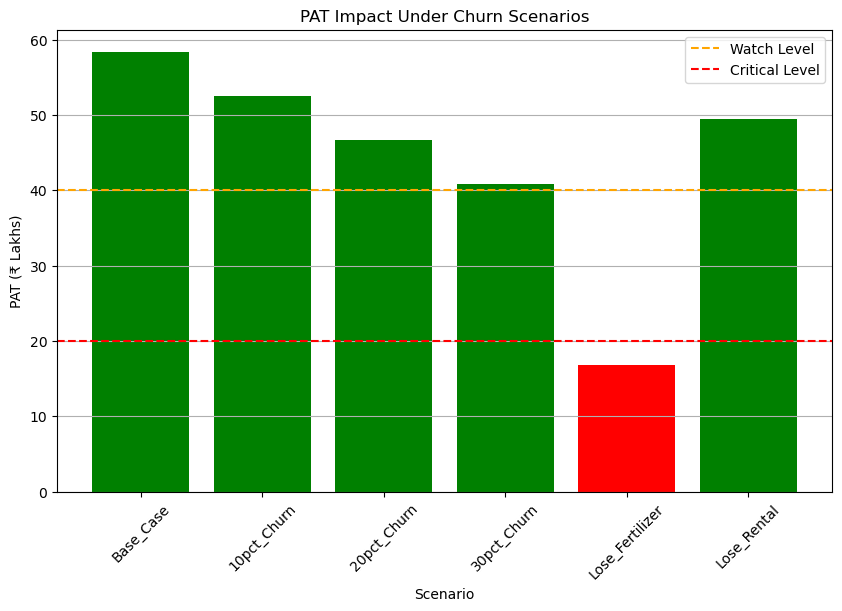

In [8]:
scenario_names = list(scenarios.keys())
scenario_pats = [total_revenue * (1 - scenarios[s]) * pat_margin / 100000 for s in scenario_names]

colors = ['green' if p > 40 else 'orange' if p > 20 else 'red' for p in scenario_pats]

plt.figure(figsize=(10, 6))
bars = plt.bar(scenario_names, scenario_pats, color=colors)
plt.title('PAT Impact Under Churn Scenarios')
plt.xlabel('Scenario')
plt.ylabel('PAT (₹ Lakhs)')
plt.xticks(rotation=45)
plt.axhline(y=40, color='orange', linestyle='--', label='Watch Level')
plt.axhline(y=20, color='red', linestyle='--', label='Critical Level')
plt.legend()
plt.grid(axis='y')
plt.savefig('scenario_impact.png')
print("Saved as scenario_impact.png")
plt.show()

In [9]:
summary = pd.DataFrame({
    'Metric': ['Total Revenue', 'Total Expenses', 'PAT', 'Top Risk', 'Break-even Churn'],
    'Value': ['₹83.43L', '₹11.00L', '₹58.40L', 'Fertilizer 71.1%', '~35%']
})

print(summary)

             Metric             Value
0     Total Revenue           ₹83.43L
1    Total Expenses           ₹11.00L
2               PAT           ₹58.40L
3          Top Risk  Fertilizer 71.1%
4  Break-even Churn              ~35%


In [12]:
# Predict retention over 7 years using exponential decay
from sklearn.metrics import mean_squared_error

years = np.arange(0, 8).reshape(-1, 1)

for stream in df['Income_Stream']:
    churn = df[df['Income_Stream'] == stream]['Churn_Risk'].values[0]
    actual = (1 - churn) ** np.arange(0, 8) * 100
    
    # Fit exponential model
    log_actual = np.log(actual)
    model = LinearRegression()
    model.fit(years, log_actual)
    
    predicted = np.exp(model.predict(years))
    mse = mean_squared_error(actual, predicted)
    
    print(f"{stream}: MSE = {mse:.4f}")

print("\nModel: Retention(t) = e^(a + b*t)")
print("Lower MSE = better fit")

Fertilizer_Sales: MSE = 0.0000
Rental_Income: MSE = 0.0000
PDS_Commission: MSE = 0.0000
Food_Grains: MSE = 0.0000
MSP_Commission: MSE = 0.0000

Model: Retention(t) = e^(a + b*t)
Lower MSE = better fit


In [1]:
import sqlite3
import pandas as pd

# Create in-memory database
conn = sqlite3.connect(':memory:')

# Create table
conn.execute('''
CREATE TABLE revenue_streams (
    stream_id INT PRIMARY KEY,
    stream_name VARCHAR(50),
    year_1_revenue DECIMAL(12,2),
    churn_rate DECIMAL(4,2),
    stability VARCHAR(20)
)
''')

# Insert data
conn.executemany('INSERT INTO revenue_streams VALUES (?,?,?,?,?)', [
    (1, 'Fertilizer_Sales', 5927862.09, 0.15, 'Medium'),
    (2, 'Rental_Income', 1279410.88, 0.10, 'High'),
    (3, 'PDS_Commission', 936447.31, 0.20, 'High'),
    (4, 'Food_Grains', 173232.00, 0.35, 'Low'),
    (5, 'MSP_Commission', 25650.00, 0.40, 'Low')
])

conn.commit()

# Query 1: Revenue concentration with ranking
query1 = '''
WITH revenue_stats AS (
    SELECT 
        stream_name,
        year_1_revenue,
        SUM(year_1_revenue) OVER () AS total_revenue,
        year_1_revenue * 100.0 / SUM(year_1_revenue) OVER () AS share_pct,
        RANK() OVER (ORDER BY year_1_revenue DESC) AS revenue_rank
    FROM revenue_streams
)
SELECT 
    stream_name,
    ROUND(share_pct, 2) AS share_pct,
    revenue_rank,
    CASE 
        WHEN share_pct > 50 THEN 'Critical'
        WHEN share_pct > 20 THEN 'High'
        WHEN share_pct > 10 THEN 'Medium'
        ELSE 'Low'
    END AS concentration_risk
FROM revenue_stats
'''

df1 = pd.read_sql(query1, conn)
print("Query 1: Revenue Concentration")
print(df1)
print()

# Query 2: Risk segmentation
query2 = '''
SELECT 
    CASE 
        WHEN churn_rate <= 0.15 THEN 'Low Risk'
        WHEN churn_rate <= 0.25 THEN 'Medium Risk'
        ELSE 'High Risk'
    END AS risk_category,
    COUNT(*) AS stream_count,
    SUM(year_1_revenue) AS total_revenue,
    AVG(churn_rate) AS avg_churn_rate
FROM revenue_streams
GROUP BY risk_category
'''

df2 = pd.read_sql(query2, conn)
print("Query 2: Risk Segmentation")
print(df2)
print()

# Query 3: Retention projection
query3 = '''
WITH RECURSIVE retention AS (
    SELECT stream_id, stream_name, churn_rate, 100.0 AS retention_pct, 0 AS year_num
    FROM revenue_streams
    UNION ALL
    SELECT 
        r.stream_id, r.stream_name, r.churn_rate,
        retention.retention_pct * (1 - r.churn_rate),
        retention.year_num + 1
    FROM revenue_streams r
    JOIN retention ON r.stream_id = retention.stream_id
    WHERE retention.year_num < 5
)
SELECT 
    stream_name,
    year_num,
    ROUND(retention_pct, 2) AS retention_pct
FROM retention
ORDER BY stream_name, year_num
'''

df3 = pd.read_sql(query3, conn)
print("Query 3: 5-Year Retention Projection")
print(df3.head(15))
print()

conn.close()
print("Done!")

Query 1: Revenue Concentration
        stream_name  share_pct  revenue_rank concentration_risk
0  Fertilizer_Sales      71.06             1           Critical
1     Rental_Income      15.34             2             Medium
2    PDS_Commission      11.22             3             Medium
3       Food_Grains       2.08             4                Low
4    MSP_Commission       0.31             5                Low

Query 2: Risk Segmentation
  risk_category  stream_count  total_revenue  avg_churn_rate
0     High Risk             2      198882.00           0.375
1      Low Risk             2     7207272.97           0.125
2   Medium Risk             1      936447.31           0.200

Query 3: 5-Year Retention Projection
         stream_name  year_num  retention_pct
0   Fertilizer_Sales         0         100.00
1   Fertilizer_Sales         1          85.00
2   Fertilizer_Sales         2          72.25
3   Fertilizer_Sales         3          61.41
4   Fertilizer_Sales         4          52.20